In [44]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [45]:
os.environ["PYTHONHASHSEED"] = str(42)
tf.random.set_seed(42)
np.random.seed(42)

In [46]:
image_folder = r"C:\Users\91909\Desktop\ML\DATA\NTIRE\test\LSDIR_DIV2K_Test_Sigma50"
save_folder = r"C:\Users\91909\Desktop\ML\DATA\NTIRE\test\NTIRE_Test_Results"

In [47]:
model_path = r"C:\Users\91909\Desktop\ML\NTIRE_2025\tf_denoiser.h5"

clean_test_path = r"C:\Users\91909\Desktop\ML\DATA\NTIRE\clean_data\DIV2K\DIV2K_valid_HR\DIV2K_valid_HR"
noisy_test_path = r"C:\Users\91909\Desktop\ML\DATA\NTIRE\noisy_data\DIV2K\DIV2K_valid_HR\DIV2K_valid_HR"

In [48]:
PATCH_SIZE = 256
OVERLAP = 64

In [49]:
def split_into_patches(image, patch_size=PATCH_SIZE, overlap=OVERLAP):
    h, w, c = image.shape
    step = patch_size - overlap
    patches = []
    coordinates = []

    for y in range(0, h - overlap, step):
        for x in range(0, w - overlap, step):
            y_end = min(y + patch_size, h)
            x_end = min(x + patch_size, w)
            patch = image[y:y_end, x:x_end]

            if patch.shape[0] < patch_size or patch.shape[1] < patch_size:
                pad_h = patch_size - patch.shape[0]
                pad_w = patch_size - patch.shape[1]
                patch = np.pad(patch, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')

            patches.append(patch)
            coordinates.append((y, x))
    
    return np.array(patches), coordinates

In [50]:
def predict_on_patches(model, patches):
    patches = patches.astype(np.float32) / 255.0
    predictions = model.predict(patches)
    predictions = np.clip(predictions * 255.0, 0, 255).astype(np.uint8)
    return predictions

In [51]:
def stitch_patches(patches, coordinates, image_shape, patch_size=PATCH_SIZE, overlap=OVERLAP):
    h, w, c = image_shape
    step = patch_size - overlap
    stitched_image = np.zeros((h, w, 3))
    weight_map = np.zeros((h, w, 1))

    for patch, (y, x) in zip(patches, coordinates):
        y_end = min(y + patch_size, h)
        x_end = min(x + patch_size, w)
        patch_h = y_end - y
        patch_w = x_end - x

        stitched_image[y:y_end, x:x_end] += patch[:patch_h, :patch_w]
        weight_map[y:y_end, x:x_end] += 1

    return np.clip(stitched_image / weight_map, 0, 255).astype(np.uint8)

In [52]:
model = load_model(model_path)

3/3 [==============================] - 3s 1s/step


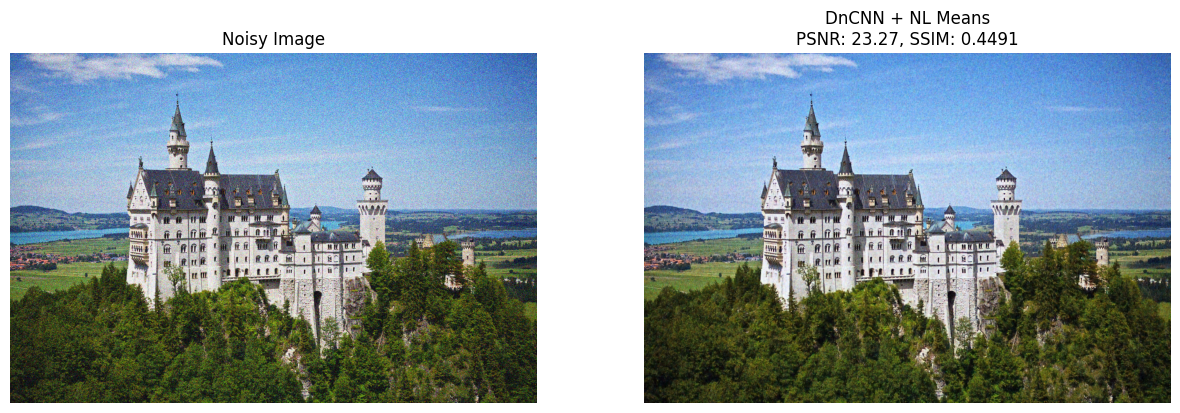

In [60]:
file_list = os.listdir(noisy_test_path)
random_file = np.random.choice(file_list)

noisy_image_path = os.path.join(noisy_test_path, random_file)
clean_image_path = os.path.join(clean_test_path, random_file)

noisy_image = cv2.imread(noisy_image_path)
noisy_image = cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB)

clean_image = cv2.imread(clean_image_path)
clean_image = cv2.cvtColor(clean_image, cv2.COLOR_BGR2RGB)

patches, coordinates = split_into_patches(noisy_image)
predictions = predict_on_patches(model, patches)
denoised_image = stitch_patches(predictions, coordinates, noisy_image.shape)


further_denoised_image = cv2.fastNlMeansDenoisingColored(
    src=denoised_image.astype(np.uint8),
    dst=None,
    h=10,
    templateWindowSize=15,
    searchWindowSize=39
)

psnr_value = psnr(clean_image, denoised_image, data_range=255)
ssim_value = ssim(clean_image, denoised_image, data_range=255, channel_axis=2)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(denoised_image)
plt.title(f"DnCNN + NL Means\nPSNR: {psnr_value:.2f}, SSIM: {ssim_value:.4f}")
plt.axis("off")

plt.show()